# 11: End-to-End Automated 3D Object Isolation Pipeline

This notebook implements the complete pipeline from a raw Aria VRS recording to isolated 3D meshes of objects of interest.

### Pipeline stages:
1. **VRS Loading & Frame Extraction** — Decode the recording, extract RGB frames at 5 fps.
2. **Eye-Gaze Alignment** — Load MPS eye-gaze data, align temporally with RGB frames.
3. **Gaze Projection & Fixation Detection** — Project gaze to 2D, detect sustained fixations via I-DT.
4. **SAM2 Segmentation** — Generate masks using multi-run mono-prompt strategy (one SAM2 session per fixation).
5. **Image Preprocessing** — Crop distortion borders for Nerfstudio compatibility.
6. **Pose Estimation** — Run COLMAP via `ns-process-data`.
7. **NeRF Training** — Train a Nerfacto model on the scene.
8. **Geometry Export** — Export dense mesh from the trained model.
9. **Semantic Projection** — Project SAM2 masks onto mesh vertices using Nerfstudio pipeline cameras with majority voting.
10. **Subject Isolation** — Extract a clean sub-mesh containing only the voted subject vertices and faces.

As a sample, we will use the `table_objects.vrs` recordings which will be downsampled to 5 FPS.

## 11.1 Recording Configuration & Setup

All paths are derived from a single `RECORDING_NAME`.

In [1]:
import os, sys, glob, gc, math, time, subprocess
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from PIL import Image
from projectaria_tools.core import data_provider, mps
from projectaria_tools.core.sensor_data import TimeDomain

# Recording identifier
RECORDING_NAME = "table_objects"
PROJECT_ROOT_ABS = r"c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1"

# Input paths
DATA_ROOT = os.path.join("..", "data", "raw", RECORDING_NAME)
VRS_PATH  = os.path.join(DATA_ROOT, f"{RECORDING_NAME}.vrs")
MPS_ROOT  = os.path.join(DATA_ROOT, f"mps_{RECORDING_NAME}_vrs")
GAZE_DIR  = os.path.join(MPS_ROOT, "eye_gaze")
GAZE_CSV  = os.path.join(GAZE_DIR, "general_eye_gaze.csv")

# Segmentation output
SEG_ROOT   = os.path.join("..", "data", "outputs", "segmentation", RECORDING_NAME)
FRAMES_DIR = os.path.join(SEG_ROOT, "frames_5fps")
MASKS_DIR  = os.path.join(SEG_ROOT, "sam2", "masks")

# Nerfstudio pipeline
NS_ROOT       = os.path.join("..", "data", "outputs", "nerfstudio", RECORDING_NAME)
IMAGES_CROPPED = os.path.join(NS_ROOT, "images_cropped")
TRAINING_DIR   = os.path.join(NS_ROOT, "training")
EXPORT_DIR     = os.path.join(NS_ROOT, "exports")

for d in [FRAMES_DIR, MASKS_DIR, IMAGES_CROPPED, TRAINING_DIR, EXPORT_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

# Validate VRS
for label, path in {"VRS": VRS_PATH, "Gaze CSV": GAZE_CSV}.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label} not found: {os.path.abspath(path)}")

print(f"Recording: {RECORDING_NAME}")
print(f"VRS: {os.path.abspath(VRS_PATH)}")
print(f"Frames: {os.path.abspath(FRAMES_DIR)}")
print(f"Masks: {os.path.abspath(MASKS_DIR)}")
print(f"NS root: {os.path.abspath(NS_ROOT)}")

Recording: table_objects
VRS: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\table_objects\table_objects.vrs
Frames: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\table_objects\frames_5fps
Masks: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\table_objects\sam2\masks
NS root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\nerfstudio\table_objects


### 11.1.1 VRS Access & Frame Extraction at 5 fps

Open the VRS, extract every 6th RGB frame (30 fps to 5 fps), and save as JPEG.

In [2]:
provider = data_provider.create_vrs_data_provider(VRS_PATH)
rgb_stream_id = provider.get_stream_id_from_label("camera-rgb")
rgb_config = provider.get_image_configuration(rgb_stream_id)
n_rgb_total = provider.get_num_data(rgb_stream_id)
IMG_W, IMG_H = rgb_config.image_width, rgb_config.image_height

print(f"RGB stream: {rgb_stream_id} | {n_rgb_total} frames | {IMG_W}x{IMG_H}")

RGB stream: 214-1 | 2764 frames | 1408x1408


In [3]:
def extract_rgb_frame(provider, stream_id, index):
    """Read one RGB frame from VRS by index, return as HxWx3 uint8 numpy array."""
    sample = provider.get_sensor_data_by_index(stream_id, index)
    for attr in ["image_data_and_record", "image_data", "image"]:
        if not hasattr(sample, attr):
            continue
        payload = getattr(sample, attr)
        payload = payload() if callable(payload) else payload
        if isinstance(payload, tuple):
            payload = payload[0]
        for arr_attr in ["to_numpy_array", "buffer"]:
            if hasattr(payload, arr_attr):
                arr = getattr(payload, arr_attr)
                arr = arr() if callable(arr) else arr
                arr = np.asarray(arr)
                if arr.ndim >= 2:
                    if arr.ndim == 3 and arr.shape[0] in (1, 3) and arr.shape[-1] not in (1, 3):
                        arr = np.transpose(arr, (1, 2, 0))
                    return arr.astype(np.uint8)
    raise RuntimeError(f"Cannot extract image at index {index}")

# Validate
test = extract_rgb_frame(provider, rgb_stream_id, 0)
print(f"Extraction OK: {test.shape}")

Extraction OK: (1408, 1408, 3)


In [4]:
SUBSAMPLE_STRIDE = 6  # 30fps / 6 = 5fps
FPS = 5.0

indices_5fps = list(range(0, n_rgb_total, SUBSAMPLE_STRIDE))
n_frames_5fps = len(indices_5fps)
print(f"Subsampling: stride={SUBSAMPLE_STRIDE} -> {n_frames_5fps} frames at {FPS} fps")

existing = len([f for f in os.listdir(FRAMES_DIR) if f.endswith(".jpg")])
if existing >= n_frames_5fps:
    print(f"Already extracted ({existing} files), skipping.")
else:
    for out_idx, vrs_idx in enumerate(indices_5fps):
        frame = extract_rgb_frame(provider, rgb_stream_id, vrs_idx)
        Image.fromarray(frame).save(os.path.join(FRAMES_DIR, f"{out_idx:06d}.jpg"), quality=95)
        if (out_idx + 1) % 100 == 0:
            print(f"  [{out_idx+1}/{n_frames_5fps}]")
    print(f"[OK] {n_frames_5fps} frames saved.")

Subsampling: stride=6 -> 461 frames at 5.0 fps
Already extracted (461 files), skipping.


In [5]:
# Build 5fps timestamp array
rgb_timestamps_ns_30fps = np.array([
    provider.get_sensor_data_by_index(rgb_stream_id, i).get_time_ns(TimeDomain.DEVICE_TIME)
    for i in range(n_rgb_total)], dtype=np.int64)

rgb_timestamps_ns = rgb_timestamps_ns_30fps[indices_5fps]
rgb_duration_s = (rgb_timestamps_ns[-1] - rgb_timestamps_ns[0]) / 1e9
rgb_rate_hz = len(rgb_timestamps_ns) / rgb_duration_s
print(f"5fps frames: {len(rgb_timestamps_ns)} | Duration: {rgb_duration_s:.2f}s | Rate: {rgb_rate_hz:.2f} Hz")

5fps frames: 461 | Duration: 91.99s | Rate: 5.01 Hz


## 11.2 Eye Gaze Loading & Temporal Alignment

Load the MPS gaze stream (~10 fps), align to the 5 fps RGB frames via nearest-timestamp matching.

In [7]:
eye_gazes = mps.read_eyegaze(GAZE_CSV)
n_gaze = len(eye_gazes)
assert n_gaze > 0, "Empty gaze CSV"
print(f"Gaze samples: {n_gaze}")

# Resolve timestamp accessor
g0 = eye_gazes[0]
if hasattr(g0, "tracking_timestamp") and hasattr(g0.tracking_timestamp, "total_seconds"):
    gaze_timestamps_ns = np.array([int(g.tracking_timestamp.total_seconds()*1e9) for g in eye_gazes], dtype=np.int64)
elif hasattr(g0, "tracking_timestamp_us"):
    gaze_timestamps_ns = np.array([g.tracking_timestamp_us * 1000 for g in eye_gazes], dtype=np.int64)
else:
    raise AttributeError("Unknown timestamp format")

gaze_rate_hz = n_gaze / ((gaze_timestamps_ns[-1] - gaze_timestamps_ns[0]) / 1e9)
print(f"Gaze rate: {gaze_rate_hz:.1f} Hz | RGB rate: {rgb_rate_hz:.1f} Hz")

# Resolve yaw/pitch accessor
if hasattr(g0, "yaw"):
    get_yaw, get_pitch = (lambda g: g.yaw), (lambda g: g.pitch)
elif hasattr(g0, "yaw_rads_cpf"):
    get_yaw, get_pitch = (lambda g: g.yaw_rads_cpf), (lambda g: g.pitch_rads_cpf)
else:
    raise AttributeError("Unknown gaze direction format")

Gaze samples: 921
Gaze rate: 10.0 Hz | RGB rate: 5.0 Hz


In [8]:
# Nearest-timestamp alignment
MAX_DELTA_MS = 60.0
insert_pos = np.clip(np.searchsorted(gaze_timestamps_ns, rgb_timestamps_ns), 1, n_gaze - 1)
delta_before = np.abs(rgb_timestamps_ns - gaze_timestamps_ns[insert_pos - 1])
delta_after  = np.abs(rgb_timestamps_ns - gaze_timestamps_ns[insert_pos])
nearest_gaze_idx = np.where(delta_before < delta_after, insert_pos - 1, insert_pos)
nearest_delta_ms = np.minimum(delta_before, delta_after) / 1e6
reliable = nearest_delta_ms < MAX_DELTA_MS

alignment = pd.DataFrame({
    "frame_idx": np.arange(len(rgb_timestamps_ns)),
    "rgb_ts_ns": rgb_timestamps_ns,
    "gaze_idx": nearest_gaze_idx,
    "delta_ms": nearest_delta_ms,
    "reliable": reliable,
    "yaw_rads": [get_yaw(eye_gazes[i]) for i in nearest_gaze_idx],
    "pitch_rads": [get_pitch(eye_gazes[i]) for i in nearest_gaze_idx],
})
print(f"Aligned: {reliable.sum()}/{len(alignment)} reliable ({100*reliable.mean():.1f}%)")

Aligned: 460/461 reliable (99.8%)


## 11.3 Gaze Projection to 2D Image Plane

Convert gaze direction (yaw/pitch in CPF) to pixel coordinates on the RGB camera using the device calibration chain.

In [9]:
device_calib = provider.get_device_calibration()
rgb_calib    = device_calib.get_camera_calib("camera-rgb")
T_device_cpf = device_calib.get_transform_device_cpf()
T_rgb_device = rgb_calib.get_transform_device_camera().inverse()

def project_gaze_to_rgb(yaw_rads, pitch_rads):
    """Project a gaze direction (CPF yaw/pitch) to a 2D pixel on the RGB camera."""
    gaze_cpf = np.array([np.tan(yaw_rads), np.tan(pitch_rads), 1.0])
    gaze_rgb = T_rgb_device @ (T_device_cpf @ gaze_cpf)
    return rgb_calib.project(gaze_rgb)

print("Projection function defined.")

Projection function defined.


In [10]:
gaze_x, gaze_y, valid_flags = [], [], []
for _, row in alignment.iterrows():
    if pd.isna(row['yaw_rads']) or pd.isna(row['pitch_rads']) or not row['reliable']:
        gaze_x.append(np.nan); gaze_y.append(np.nan); valid_flags.append(False)
        continue
    px = project_gaze_to_rgb(row['yaw_rads'], row['pitch_rads'])
    if px is not None:
        u, v = px[0], px[1]
        ok = (0 <= u < IMG_W) and (0 <= v < IMG_H)
        gaze_x.append(u); gaze_y.append(v); valid_flags.append(ok)
    else:
        gaze_x.append(np.nan); gaze_y.append(np.nan); valid_flags.append(False)

alignment['gaze_x'] = gaze_x
alignment['gaze_y'] = gaze_y
alignment['valid_gaze'] = valid_flags
print(f"Valid gaze projections: {sum(valid_flags)}/{len(alignment)}")

Valid gaze projections: 460/461


## 11.4 Fixation Detection (I-DT Algorithm)

Dispersion-based fixation detection: a fixation is registered when the gaze remains within a spatial threshold for a minimum duration. Uses Manhattan dispersion and median centroid for robustness.

In [11]:
def detect_fixations_idt(df, dispersion_threshold, min_duration_frames):
    """I-DT fixation detector with Manhattan dispersion and median centroid."""
    fixations = []
    valid_mask = df['valid_gaze'].values
    xs, ys = df['gaze_x'].values, df['gaze_y'].values
    frames = df['frame_idx'].values
    n = len(frames)
    i = 0
    while i <= n - min_duration_frames:
        if not all(valid_mask[i : i + min_duration_frames]):
            i += 1; continue
        wx = xs[i : i + min_duration_frames].tolist()
        wy = ys[i : i + min_duration_frames].tolist()
        disp = (max(wx)-min(wx)) + (max(wy)-min(wy))
        if disp <= dispersion_threshold:
            j = i + min_duration_frames
            while j < n and valid_mask[j]:
                wx.append(xs[j]); wy.append(ys[j])
                if (max(wx)-min(wx))+(max(wy)-min(wy)) > dispersion_threshold:
                    wx.pop(); wy.pop(); break
                j += 1
            fixations.append({
                'start_frame': int(frames[i]), 'end_frame': int(frames[j-1]),
                'centroid_x': float(np.median(wx)), 'centroid_y': float(np.median(wy)),
                'duration_frames': j - i
            })
            i = j
        else:
            i += 1
    return fixations

print("I-DT fixation detector defined.")

I-DT fixation detector defined.


In [26]:
# Fixation parameters
FIXATION_DURATION_SEC = 4.75
FIXATION_DISPERSION_PX = 200.0
FIXATION_MIN_FRAMES = math.ceil(FIXATION_DURATION_SEC * FPS)

print(f"Thresholds: {FIXATION_DURATION_SEC}s ({FIXATION_MIN_FRAMES} frames), {FIXATION_DISPERSION_PX}px")

fixations = detect_fixations_idt(alignment, FIXATION_DISPERSION_PX, FIXATION_MIN_FRAMES)
df_fix = pd.DataFrame(fixations)
df_fix['duration_s'] = df_fix['duration_frames'] / FPS
df_fix['object_id'] = range(1, len(df_fix) + 1)

# Use the mid-frame of each fixation as the SAM2 prompt frame
df_fix['mid_frame'] = ((df_fix['start_frame'] + df_fix['end_frame']) // 2).astype(int)

df_fix = df_fix.sort_values('start_frame').reset_index(drop=True)

print(f"\nDetected {len(df_fix)} fixations:")
print(df_fix[['object_id','start_frame','mid_frame','end_frame','duration_s','centroid_x','centroid_y']].to_string(index=False))

Thresholds: 4.75s (24 frames), 200.0px

Detected 2 fixations:
 object_id  start_frame  mid_frame  end_frame  duration_s  centroid_x  centroid_y
         1           81         92        104         4.8  784.563679   718.60862
         2          360        387        415        11.2  747.599804   698.30356


### 11.4.2 Visualize Detected Fixations

Overlay each fixation centroid on the **mid-frame** of the fixation window. The mid-frame provides the most representative view of the object being fixated, and is the frame that will be used as the SAM2 prompt origin.

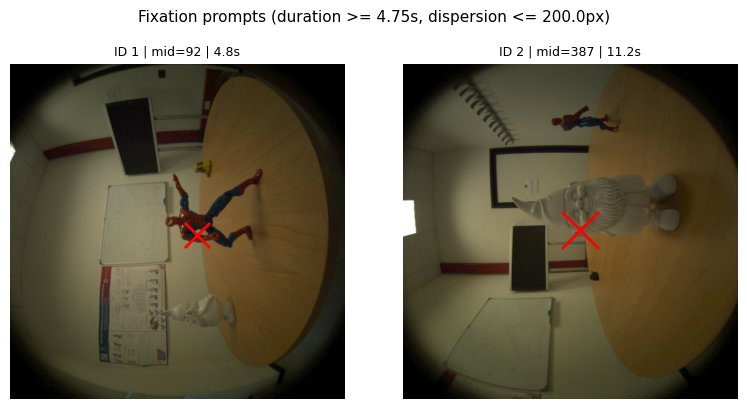

2 fixations visualized on their mid-frames.


In [36]:
import matplotlib.pyplot as plt

n_fix = len(df_fix)
cols = min(n_fix, 4)
rows = math.ceil(n_fix / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
if n_fix == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, (_, row) in enumerate(df_fix.iterrows()):
    frame_path = os.path.join(FRAMES_DIR, f"{int(row['mid_frame']):06d}.jpg")
    if not os.path.exists(frame_path):
        axes[i].set_title(f"Frame {int(row['mid_frame'])} missing", fontsize=9)
        axes[i].axis("off")
        continue

    img = np.array(Image.open(frame_path))
    axes[i].imshow(img)

    marker_size = 40 + row['duration_s'] * 60
    axes[i].scatter(row['centroid_x'], row['centroid_y'],
                    s=marker_size, c='red', marker='x', linewidths=2)

    axes[i].set_title(
        f"ID {int(row['object_id'])} | mid={int(row['mid_frame'])} | {row['duration_s']:.1f}s",
        fontsize=9)
    axes[i].axis("off")

for j in range(n_fix, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Fixation prompts (duration >= {FIXATION_DURATION_SEC}s, dispersion <= {FIXATION_DISPERSION_PX}px)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print(f"{n_fix} fixations visualized on their mid-frames.")

## 11.5 SAM2 Segmentation adopting Multi-Run Mono-Prompt

Each fixation is tracked independently in its own SAM2 session. This prevents inter-object interference during propagation. Per-object binary masks are merged into unified multi-label masks at the end.

In [28]:
sam2_prompts = []
for _, row in df_fix.iterrows():
    sam2_prompts.append({
        'object_id': int(row['object_id']),
        'init_frame_idx': int(row['mid_frame']),
        'point_coords': [float(row['centroid_x']), float(row['centroid_y'])],
        'point_labels': [1],
    })
for p in sam2_prompts:
    c = [round(x,1) for x in p['point_coords']]
    print(f"  ID {p['object_id']:02d} | prompt frame {p['init_frame_idx']} | {c}")

  ID 01 | prompt frame 92 | [784.6, 718.6]
  ID 02 | prompt frame 387 | [747.6, 698.3]


In [29]:
import torch
from sam2.build_sam import build_sam2_video_predictor

CHECKPOINT = os.path.join(PROJECT_ROOT_ABS, "checkpoints", "sam2_hiera_small.pt")
SAM2_CONFIG = os.path.join(PROJECT_ROOT_ABS, "third_party", "sam2", "sam2", "configs", "sam2", "sam2_hiera_s.yaml")

device = "cuda" if torch.cuda.is_available() else "cpu"
predictor = build_sam2_video_predictor(SAM2_CONFIG, CHECKPOINT, device=device)
print(f"SAM2 loaded on {device}")

SAM2 loaded on cuda


In [30]:
gc.collect(); torch.cuda.empty_cache()
inference_state = predictor.init_state(
    video_path=FRAMES_DIR, offload_video_to_cpu=True, offload_state_to_cpu=True)
predictor.reset_state(inference_state)
print(f"Video state initialized: {FRAMES_DIR}")

frame loading (JPEG): 100%|██████████| 461/461 [00:31<00:00, 14.82it/s]


Video state initialized: ..\data\outputs\segmentation\table_objects\frames_5fps


In [31]:
def run_single_prompt(predictor, state, prompt):
    """Run SAM2 forward and backward for one prompt. Returns {frame_idx: bool_mask}."""
    predictor.reset_state(state)
    predictor.add_new_points_or_box(
        inference_state=state, frame_idx=prompt['init_frame_idx'],
        obj_id=prompt['object_id'],
        points=np.array([prompt['point_coords']], dtype=np.float32),
        labels=np.array(prompt['point_labels'], dtype=np.int32))
    masks = {}
    init = prompt['init_frame_idx']
    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        for fi, _, ml in predictor.propagate_in_video(state):
            if int(fi) >= init:
                masks[int(fi)] = (ml[0,0]>0).detach().cpu().numpy()
        for fi, _, ml in predictor.propagate_in_video(state, start_frame_idx=init, reverse=True):
            if int(fi) < init:
                masks[int(fi)] = (ml[0,0]>0).detach().cpu().numpy()
    return masks

print("run_single_prompt() defined.")

run_single_prompt() defined.


In [32]:
per_object_masks = {}
for pi, prompt in enumerate(sam2_prompts):
    print(f"[{pi+1}/{len(sam2_prompts)}] Object {prompt['object_id']:02d}...", end=" ")
    t0 = time.time()
    masks = run_single_prompt(predictor, inference_state, prompt)
    per_object_masks[prompt['object_id']] = masks
    n_active = sum(1 for m in masks.values() if m.any())
    print(f"{n_active} active frames ({time.time()-t0:.1f}s)")
print("All runs complete.")

[1/2] Object 01... 

c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 93/93 [01:07<00:00,  1.38it/s]


461 active frames (244.5s)
[2/2] Object 02... 

propagate in video: 100%|██████████| 388/388 [04:44<00:00,  1.36it/s]


461 active frames (338.0s)
All runs complete.


### 11.5.2 Mask Merging & Export

In [33]:
def apply_palette_and_save(frame_idx, label_mask, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    img = Image.fromarray(label_mask, mode='P')
    pal = [0,0,0, # Background (ID 0)
        255,0,0, # red
        0,255,0, # green
        0,100,255, # blue
        255,255,0, # yellow
        255,0,255, # magenta
        0,255,255, # cyan
        255,128,0, # orange
        128,0,255, # purple
        0,255,128] # light green
    pal += [0]*(768-len(pal))
    img.putpalette(pal)
    img.save(os.path.join(output_dir, f"{int(frame_idx):06d}.png"), compress_level=1)

# Merge per-object masks into unified label masks
all_frames = set()
for m in per_object_masks.values(): all_frames.update(m.keys())
sample = next(iter(next(iter(per_object_masks.values())).values()))
h, w = sample.shape

for fi in sorted(all_frames):
    lm = np.zeros((h, w), dtype=np.uint8)
    for oid in sorted(per_object_masks):
        if fi in per_object_masks[oid]:
            lm[per_object_masks[oid][fi]] = oid
    apply_palette_and_save(fi, lm, MASKS_DIR)

print(f"[OK] {len(all_frames)} masks exported to: {MASKS_DIR}")

[OK] 461 masks exported to: ..\data\outputs\segmentation\table_objects\sam2\masks


In [34]:
# Free SAM2 from GPU
del predictor, inference_state
gc.collect(); torch.cuda.empty_cache()
print("SAM2 released.")

SAM2 released.
